# 30_meta_1d_mass_rl2_seqppo

Düzeltilmiş RL² + sekans tabanlı PPO (TBPTT tarzı) ile 1D kütle ortamı.

- Ortam: 1D point-mass, kütle m değişiyor, sürtünme b ve hedef x_goal sabit.
- Ajan: GRU tabanlı RL² policy (augmented observation: [x, v, a_prev, r_prev, d_prev]).
- PPO: Sekans tabanlı, zaman sırasını bozmadan ve GRU'yu stateful kullanarak güncelleme.
- Truncated BPTT: Uzun trajectory, sabit uzunluklu segmentlere bölünüp her segmentte ayrı backward/step.


In [18]:
import os
import random
import warnings
from dataclasses import dataclass

import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.distributions.normal import Normal

warnings.filterwarnings('ignore')

device = 'cuda' if torch.cuda.is_available() else ('mps' if torch.backends.mps.is_available() else 'cpu')
print('Device:', device)

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if device == 'cuda':
    torch.cuda.manual_seed_all(SEED)


Device: cuda


## Hiperparametreler ve ortam ayarları


In [19]:
# Meta-RL (RL²) hiperparametreleri
META_BATCH_SIZE   = 8      # her meta-iterasyonda kaç farklı task (farklı m)
EPISODES_PER_TASK = 4      # her task için ardışık epizot sayısı (aynı GRU hidden state)
ROLLOUT_LEN       = 100    # her epizotta maksimum step
TOTAL_ITERS       = 200    # meta-iterasyon sayısı

GAMMA       = 0.99
LAMBDA_GAE  = 0.95
PPO_EPOCHS  = 2 # 4
PPO_CLIP    = 0.2
PPO_LR      = 1e-4 # 3e-4
HIDDEN_SIZE = 64

# Sekans tabanlı PPO (TBPTT) için segment uzunluğu
SEG_LEN = 32   # truncated BPTT segment uzunluğu (step sayısı)

# Ortam parametreleri
DT          = 0.05
MAX_STEPS   = ROLLOUT_LEN
ACTION_LOW  = -2.0
ACTION_HIGH =  2.0

# Task dağılımı: sadece kütle m değişiyor; b ve x_goal sabit
M_VALUES   = [1.0, 2.0, 3.0]
B_FIXED    = 0.3
X_GOAL_FIX = 2.0


## 1D kütle ortamı ve task tanımı (sadece m değişiyor)


In [20]:
@dataclass
class MassTask:
    m: float
    b: float
    x_goal: float

def sample_task():
    m = random.choice(M_VALUES)
    b = B_FIXED
    xg = X_GOAL_FIX
    return MassTask(m, b, xg)

class OneDMassEnv:
    def __init__(self, task: MassTask):
        self.task = task
        self.dt   = DT
        self.max_steps = MAX_STEPS
        self.action_low  = ACTION_LOW
        self.action_high = ACTION_HIGH
        self.t = 0
        self.x = 0.0
        self.v = 0.0

    def reset(self, seed=None):
        if seed is not None:
            np.random.seed(seed)
        self.x = np.random.uniform(-0.5, 0.5)
        self.v = np.random.uniform(-0.5, 0.5)
        self.t = 0
        obs = np.array([self.x, self.v], dtype=np.float32)
        return obs, {}
    

    def step(self, u):
        u = float(np.clip(u, self.action_low, self.action_high))
        m = self.task.m
        b = self.task.b
        xg = self.task.x_goal

        # Dinamik: m * dv/dt = u - b * v
        a = (u - b * self.v) / m
        self.v = self.v + a * self.dt
        self.x = self.x + self.v * self.dt
        self.t += 1

        dist2 = (self.x - xg) ** 2
        r = -dist2

        done = self.t >= self.max_steps
        trunc = False
        obs = np.array([self.x, self.v], dtype=np.float32)
        info = {'task': self.task}
        return obs, float(r), bool(done), bool(trunc), info
    def close(self):
        # Gym uyumluluğu için boş bırakıyoruz
        pass

print('Örnek task:', sample_task())
env_dbg = OneDMassEnv(sample_task())
s_dbg, _ = env_dbg.reset()
print('Initial state:', s_dbg, '| task:', env_dbg.task)


Örnek task: MassTask(m=3.0, b=0.3, x_goal=2.0)
Initial state: [-0.12545988  0.45071432] | task: MassTask(m=1.0, b=0.3, x_goal=2.0)


## RL² girdi yapısı: augmented observation


In [21]:
def make_initial_history(action_dim: int):
    a_prev = np.zeros((action_dim,), dtype=np.float32)
    r_prev = np.array([0.0], dtype=np.float32)
    d_prev = np.array([0.0], dtype=np.float32)
    return a_prev, r_prev, d_prev

def augment_obs(obs, a_prev, r_prev, d_prev):
    return np.concatenate([obs, a_prev, r_prev, d_prev], axis=-1).astype(np.float32)

test_task = sample_task()
test_env  = OneDMassEnv(test_task)
s0, _ = test_env.reset(seed=SEED)
a_prev, r_prev, d_prev = make_initial_history(action_dim=1)
aug0 = augment_obs(s0, a_prev, r_prev, d_prev)
print('Augmented obs shape:', aug0.shape)


Augmented obs shape: (5,)


## RL² policy: GRU tabanlı policy + value ağı


In [22]:
class RL2RecurrentPolicy(nn.Module):
    def __init__(self, input_dim: int, action_dim: int, hidden_size: int = 64):
        super().__init__()
        self.hidden_size = hidden_size
        self.action_dim  = action_dim

        self.fc_in = nn.Linear(input_dim, hidden_size)
        self.gru   = nn.GRU(hidden_size, hidden_size, batch_first=True)

        self.fc_pi   = nn.Linear(hidden_size, action_dim)
        self.log_std = nn.Parameter(torch.zeros(action_dim))
        self.fc_v    = nn.Linear(hidden_size, 1)

    def initial_hidden(self, batch_size: int = 1, device: str = 'cpu'):
        return torch.zeros(1, batch_size, self.hidden_size, device=device)

    def forward_step(self, x_t: torch.Tensor, h: torch.Tensor):
        # x_t: (B, input_dim), h: (1, B, H)
        z = torch.relu(self.fc_in(x_t))
        z = z.unsqueeze(1)              # (B, 1, H)
        out, h_next = self.gru(z, h)    # out: (B, 1, H)
        out = out.squeeze(1)            # (B, H)

        mean = self.fc_pi(out)
        std  = self.log_std.exp().unsqueeze(0)
        dist = Normal(mean, std)
        action = dist.sample()
        logp   = dist.log_prob(action).sum(dim=-1)
        value  = self.fc_v(out).squeeze(-1)
        return action, logp, value, h_next

    def act_deterministic(self, x_t: torch.Tensor, h: torch.Tensor):
        z = torch.relu(self.fc_in(x_t))
        z = z.unsqueeze(1)
        out, h_next = self.gru(z, h)
        out = out.squeeze(1)
        mean  = self.fc_pi(out)
        value = self.fc_v(out).squeeze(-1)
        return mean, value, h_next

policy_dbg = RL2RecurrentPolicy(input_dim=aug0.shape[0], action_dim=1, hidden_size=HIDDEN_SIZE).to(device)
h0_dbg = policy_dbg.initial_hidden(batch_size=1, device=device)
x_dbg = torch.tensor(aug0, dtype=torch.float32, device=device).unsqueeze(0)
a_dbg, logp_dbg, v_dbg, h1_dbg = policy_dbg.forward_step(x_dbg, h0_dbg)
print('Policy debug action/val/logp:', a_dbg.detach().cpu().numpy(), v_dbg.item(), logp_dbg.item())


Policy debug action/val/logp: [[0.18763012]] 0.06070077046751976 -0.9377601742744446


## RL² Ajanı: collect_batch + sekans tabanlı PPO (TBPTT)


In [23]:
class RL2Agent:
    def __init__(self, input_dim, action_dim, hidden_size=HIDDEN_SIZE, lr=PPO_LR, device=device):
        self.device = device
        self.policy = RL2RecurrentPolicy(input_dim, action_dim, hidden_size).to(device)
        self.optim  = torch.optim.Adam(self.policy.parameters(), lr=lr)

    def collect_batch(self,
                       meta_batch_size=META_BATCH_SIZE,
                       episodes_per_task=EPISODES_PER_TASK,
                       rollout_len=ROLLOUT_LEN):
        obs_buf, act_buf, logp_buf, rew_buf, val_buf, done_buf = [], [], [], [], [], []
        z_buf = []
        m_buf = []
        task_start_buf = []

        ep_returns_per_task = []

        for task_idx in range(meta_batch_size):
            task = sample_task()
            env  = OneDMassEnv(task)
            action_dim = 1

            h = self.policy.initial_hidden(batch_size=1, device=self.device)
            first_step_of_task = True

            task_ep_returns = []
            for ep in range(episodes_per_task):
                s, _ = env.reset(seed=SEED + task_idx * 100 + ep)
                prev_a, prev_r, prev_d = make_initial_history(action_dim)
                ep_ret = 0.0

                for t in range(rollout_len):
                    aug = augment_obs(s, prev_a, prev_r, prev_d)
                    x_t = torch.tensor(aug, dtype=torch.float32, device=self.device).unsqueeze(0)
                    with torch.no_grad():
                        a_t, logp_t, v_t, h = self.policy.forward_step(x_t, h)
                    a_np = a_t.squeeze(0).cpu().numpy()
                    ns, r, done, trunc, info = env.step(a_np[0])

                    if first_step_of_task:
                        task_start_buf.append(1.0)
                        first_step_of_task = False
                    else:
                        task_start_buf.append(0.0)

                    obs_buf.append(aug)
                    act_buf.append(a_np)
                    logp_buf.append(logp_t.cpu().numpy())
                    rew_buf.append(r)
                    val_buf.append(v_t.cpu().numpy())
                    done_flag = float(done or trunc)
                    done_buf.append(done_flag)

                    z_buf.append(h.squeeze(0).squeeze(0).detach().cpu().numpy())
                    m_buf.append(task.m)

                    ep_ret += r

                    prev_a = np.array([a_np[0]], dtype=np.float32)
                    prev_r = np.array([r], dtype=np.float32)
                    prev_d = np.array([done_flag], dtype=np.float32)
                    s = ns
                    if done or trunc:
                        break

                task_ep_returns.append(ep_ret)

            ep_returns_per_task.append(task_ep_returns)
            env.close()

        batch = {
            'obs':        torch.tensor(np.stack(obs_buf), dtype=torch.float32, device=self.device),
            'act':        torch.tensor(np.stack(act_buf), dtype=torch.float32, device=self.device),
            'logp':       torch.tensor(np.stack(logp_buf).squeeze(-1), dtype=torch.float32, device=self.device),
            'rew':        torch.tensor(np.array(rew_buf), dtype=torch.float32, device=self.device),
            'val':        torch.tensor(np.stack(val_buf).squeeze(-1), dtype=torch.float32, device=self.device),
            'done':       torch.tensor(np.array(done_buf), dtype=torch.float32, device=self.device),
            'z':          torch.tensor(np.stack(z_buf), dtype=torch.float32, device=self.device),
            'm':          torch.tensor(np.array(m_buf), dtype=torch.float32, device=self.device),
            'task_start': torch.tensor(np.array(task_start_buf), dtype=torch.float32, device=self.device)
        }

        return batch, ep_returns_per_task

    def compute_gae(self, rew, val, done, gamma=GAMMA, lam=LAMBDA_GAE):
        T = len(rew)
        adv = torch.zeros(T, dtype=torch.float32, device=rew.device)
        last_gae = 0.0
        for t in reversed(range(T)):
            nonterminal = 1.0 - done[t]
            if t == T - 1:
                next_value = 0.0
            else:
                next_value = val[t + 1]
            delta = rew[t] + gamma * next_value * nonterminal - val[t]
            last_gae = delta + gamma * lam * nonterminal * last_gae
            adv[t] = last_gae
        ret = adv + val
        return adv, ret

    def ppo_update(self, batch, epochs=PPO_EPOCHS, clip_ratio=PPO_CLIP, seg_len=SEG_LEN):
        obs        = batch['obs']
        act        = batch['act']
        old_logp   = batch['logp']
        rew        = batch['rew']
        val        = batch['val']
        done       = batch['done']
        task_start = batch['task_start']

        adv, ret = self.compute_gae(rew, val, done)
        adv = (adv - adv.mean()) / (adv.std() + 1e-8)
        ret = (ret - ret.mean()) / (ret.std() + 1e-8) ## --- Edited line ---
        T = obs.shape[0]

        last_pi_loss = 0.0
        last_v_loss  = 0.0

        for ep in range(epochs):
            h = self.policy.initial_hidden(batch_size=1, device=self.device)
            t = 0
            while t < T:
                seg_start = t
                seg_end   = min(t + seg_len, T)

                self.optim.zero_grad()
                seg_policy_losses = []
                seg_value_losses  = []
                seg_entropies     = []

                while t < seg_end:
                    if task_start[t] > 0.5:
                        h = self.policy.initial_hidden(batch_size=1, device=self.device)

                    x_t        = obs[t].unsqueeze(0)
                    a_t        = act[t].unsqueeze(0)
                    adv_t      = adv[t].unsqueeze(0)
                    ret_t      = ret[t].unsqueeze(0)
                    old_logp_t = old_logp[t].unsqueeze(0)

                    mean_t, v_t, h = self.policy.act_deterministic(x_t, h)
                    dist  = Normal(mean_t, self.policy.log_std.exp().unsqueeze(0))
                    logp_t = dist.log_prob(a_t).sum(dim=-1)

                    ratio = torch.exp(logp_t - old_logp_t)
                    surr1 = ratio * adv_t
                    surr2 = torch.clamp(ratio, 1.0 - clip_ratio, 1.0 + clip_ratio) * adv_t
                    policy_loss_t = -torch.min(surr1, surr2).mean()
                    value_loss_t  = F.mse_loss(v_t.squeeze(-1), ret_t)
                    entropy_t     = dist.entropy().sum(dim=-1).mean()

                    seg_policy_losses.append(policy_loss_t)
                    seg_value_losses.append(value_loss_t)
                    seg_entropies.append(entropy_t)

                    t += 1

                if len(seg_policy_losses) == 0:
                    break

                policy_loss = torch.stack(seg_policy_losses).mean()
                value_loss  = torch.stack(seg_value_losses).mean()
                entropy     = torch.stack(seg_entropies).mean()

                loss = policy_loss + 0.5 * value_loss - 0.01 * entropy

                loss.backward()
                nn.utils.clip_grad_norm_(self.policy.parameters(), 0.5) ## 1.0 0.5 yapıldı
                self.optim.step()

                h = h.detach()

                last_pi_loss = float(policy_loss.item())
                last_v_loss  = float(value_loss.item())

        return last_pi_loss, last_v_loss

input_dim  = 2 + 1 + 1 + 1
action_dim = 1
agent = RL2Agent(input_dim=input_dim, action_dim=action_dim, hidden_size=HIDDEN_SIZE, lr=PPO_LR, device=device)
print('RL2Agent hazır.')


RL2Agent hazır.


## Eğitim döngüsü


In [24]:
avg_return_history = []
last_ep_return_history = []
pi_loss_history = []
v_loss_history  = []

z_all = []
m_all = []

for it in range(1, TOTAL_ITERS + 1):
    batch, ep_returns_per_task = agent.collect_batch()
    pi_loss, v_loss = agent.ppo_update(batch)

    # --- Güvenli ortalama hesaplama ---
    flat_returns = []
    last_eps = []
    for eps in ep_returns_per_task:
        if len(eps) > 0:
            flat_returns.extend(eps)   # tüm epizotların return'ları
            last_eps.append(eps[-1])  # her task için son epizot return'u

    if len(flat_returns) > 0:
        avg_ret = float(np.mean(flat_returns))
    else:
        avg_ret = 0.0

    if len(last_eps) > 0:
        last_ep_ret = float(np.mean(last_eps))
    else:
        last_ep_ret = 0.0

    avg_return_history.append(avg_ret)
    last_ep_return_history.append(last_ep_ret)
    pi_loss_history.append(pi_loss)
    v_loss_history.append(v_loss)

    # --- z ve m gerçekten varsa kaydet ---
    if 'z' in batch and 'm' in batch:
        z_all.append(batch['z'].detach().cpu().numpy())
        m_all.append(batch['m'].detach().cpu().numpy())

    if it % 10 == 0:
        print(
            f'Iter {it:04d} | '
            f'avg_ret={avg_ret:.3f} | '
            f'last_ep_ret={last_ep_ret:.3f} | '
            f'pi_loss={pi_loss:.3f} | v_loss={v_loss:.3f}'
        )

# --- t-SNE için latent durumları ancak veri varsa birleştir ---
if len(z_all) > 0:
    z_all = np.concatenate(z_all, axis=0)
    m_all = np.concatenate(m_all, axis=0)
    print('Toplam z_all shape:', z_all.shape)
else:
    print('z_all boş, henüz latent state kaydı yok (t-SNE için veri toplanmadı).')

Iter 0010 | avg_ret=-357.812 | last_ep_ret=-321.244 | pi_loss=-0.792 | v_loss=0.020
Iter 0020 | avg_ret=-312.779 | last_ep_ret=-309.718 | pi_loss=0.037 | v_loss=0.284
Iter 0030 | avg_ret=-294.070 | last_ep_ret=-287.104 | pi_loss=-0.311 | v_loss=0.032
Iter 0040 | avg_ret=-246.450 | last_ep_ret=-186.175 | pi_loss=-0.613 | v_loss=0.002
Iter 0050 | avg_ret=-230.216 | last_ep_ret=-210.299 | pi_loss=-0.645 | v_loss=0.001
Iter 0060 | avg_ret=-250.077 | last_ep_ret=-156.216 | pi_loss=-0.569 | v_loss=0.001
Iter 0070 | avg_ret=-212.916 | last_ep_ret=-214.139 | pi_loss=-0.743 | v_loss=0.014
Iter 0080 | avg_ret=-186.643 | last_ep_ret=-205.480 | pi_loss=-0.454 | v_loss=0.011
Iter 0090 | avg_ret=-164.096 | last_ep_ret=-133.634 | pi_loss=-0.703 | v_loss=0.016
Iter 0100 | avg_ret=-148.296 | last_ep_ret=-127.984 | pi_loss=-0.803 | v_loss=0.020
Iter 0110 | avg_ret=-127.152 | last_ep_ret=-111.634 | pi_loss=-0.638 | v_loss=0.026
Iter 0120 | avg_ret=-136.259 | last_ep_ret=-111.037 | pi_loss=-0.597 | v_loss

## Öğrenme eğrileri


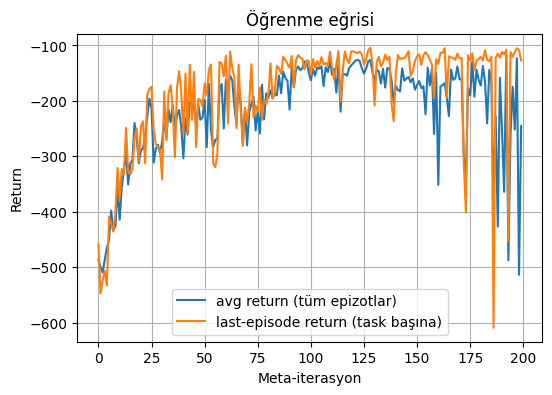

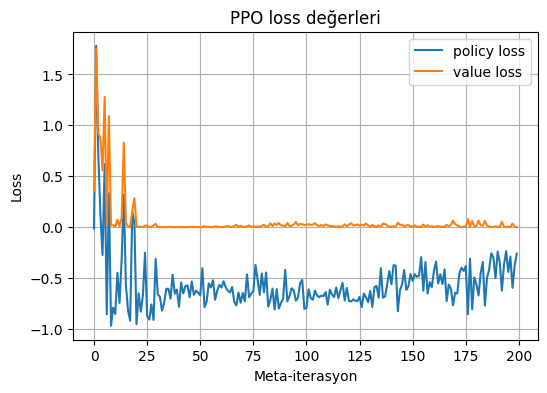

In [25]:
plt.figure(figsize=(6, 4))
plt.plot(avg_return_history, label='avg return (tüm epizotlar)')
plt.plot(last_ep_return_history, label='last-episode return (task başına)')
plt.xlabel('Meta-iterasyon')
plt.ylabel('Return')
plt.title('Öğrenme eğrisi')
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(6, 4))
plt.plot(pi_loss_history, label='policy loss')
plt.plot(v_loss_history, label='value loss')
plt.xlabel('Meta-iterasyon')
plt.ylabel('Loss')
plt.title('PPO loss değerleri')
plt.legend()
plt.grid(True)
plt.show()


In [28]:
# Bu, RL2RecurrentPolicy'nin YERİNE GEÇER
# (Hafızasız, sadece MLP)
class StatelessPPOPolicy(nn.Module):
    def __init__(self, obs_dim: int, action_dim: int, hidden_size: int = 64):
        super().__init__()
        self.action_dim = action_dim

        self.fc_in = nn.Linear(obs_dim, hidden_size)
        
        # GRU KATMANI YOK

        self.fc_pi   = nn.Linear(hidden_size, action_dim)
        self.log_std = nn.Parameter(torch.zeros(action_dim))
        self.fc_v    = nn.Linear(hidden_size, 1)

    def forward(self, x_t: torch.Tensor):
        # x_t: (B, obs_dim)
        
        # GİZLİ DURUM (h) YOK
        z = torch.relu(self.fc_in(x_t))
        
        mean = self.fc_pi(z)
        std  = self.log_std.exp().unsqueeze(0).expand_as(mean)
        dist = Normal(mean, std)
        
        value  = self.fc_v(z).squeeze(-1) # (B,)
        
        return dist, value

    def act_deterministic(self, x_t: torch.Tensor):
        z = torch.relu(self.fc_in(x_t))
        mean  = self.fc_pi(z)
        value = self.fc_v(z).squeeze(-1)
        return mean, value

In [29]:
# Yeni Hiperparametreler (RL² yerine)
STEPS_PER_BATCH = 4096  # Her iterasyonda toplanacak toplam adım sayısı
MINIBATCH_SIZE  = 64    # PPO update için mini-batch boyutu

class StandardPPOAgent:
    def __init__(self, obs_dim, action_dim, hidden_size=HIDDEN_SIZE, lr=PPO_LR, device=device):
        self.device = device
        self.obs_dim = obs_dim
        self.action_dim = action_dim
        
        # Yeni hafızasız politikayı kullan
        self.policy = StatelessPPOPolicy(obs_dim, action_dim, hidden_size).to(device)
        self.optim  = torch.optim.Adam(self.policy.parameters(), lr=lr)

    # GAE hesaplaması aynı, kopyalayabiliriz
    def compute_gae(self, rew, val, done, gamma=GAMMA, lam=LAMBDA_GAE):
        T = len(rew)
        adv = torch.zeros(T, dtype=torch.float32, device=rew.device)
        last_gae = 0.0
        for t in reversed(range(T)):
            nonterminal = 1.0 - done[t]
            if t == T - 1:
                next_value = 0.0
            else:
                next_value = val[t + 1]
            delta = rew[t] + gamma * next_value * nonterminal - val[t]
            last_gae = delta + gamma * lam * nonterminal * last_gae
            adv[t] = last_gae
        ret = adv + val
        return adv, ret

    def collect_batch(self, steps_per_batch=STEPS_PER_BATCH):
        obs_buf   = torch.zeros((steps_per_batch, self.obs_dim), dtype=torch.float32, device=self.device)
        act_buf   = torch.zeros((steps_per_batch, self.action_dim), dtype=torch.float32, device=self.device)
        logp_buf  = torch.zeros(steps_per_batch, dtype=torch.float32, device=self.device)
        rew_buf   = torch.zeros(steps_per_batch, dtype=torch.float32, device=self.device)
        val_buf   = torch.zeros(steps_per_batch, dtype=torch.float32, device=self.device)
        done_buf  = torch.zeros(steps_per_batch, dtype=torch.float32, device=self.device)

        # --- Geçici Çevre Değişkenleri ---
        # (Not: Bu baseline, RL² gibi "görev başına N epizot" mantığına sahip DEĞİL.
        # Sadece rastgele görevlerde adımları tamamlar)
        task = sample_task()
        env  = OneDMassEnv(task)
        s, _ = env.reset()
        current_step = 0
        ep_returns = []
        current_ep_ret = 0.0

        while current_step < steps_per_batch:
            x_t = torch.tensor(s, dtype=torch.float32, device=self.device).unsqueeze(0)
            
            with torch.no_grad():
                dist, v_t = self.policy.forward(x_t)
                a_t = dist.sample()
                logp_t = dist.log_prob(a_t).sum(dim=-1)

            a_np = a_t.squeeze(0).cpu().numpy()
            ns, r, done, trunc, info = env.step(a_np[0])

            # Verileri buffer'a kaydet
            obs_buf[current_step] = torch.tensor(s, device=self.device)
            act_buf[current_step] = a_t
            logp_buf[current_step] = logp_t
            rew_buf[current_step] = r
            val_buf[current_step] = v_t
            done_buf[current_step] = float(done or trunc)
            
            s = ns
            current_ep_ret += r
            current_step += 1

            if done or trunc:
                ep_returns.append(current_ep_ret)
                current_ep_ret = 0.0
                # Yeni bir epizot, yeni bir görev
                task = sample_task()
                env = OneDMassEnv(task) # Env'i yeni task ile yeniden kur
                s, _ = env.reset()

        env.close()

        batch = {
            'obs': obs_buf,
            'act': act_buf,
            'logp': logp_buf,
            'rew': rew_buf,
            'val': val_buf,
            'done': done_buf
        }
        return batch, ep_returns

    def ppo_update(self, batch, epochs=PPO_EPOCHS, clip_ratio=PPO_CLIP, seg_len=None): # seg_len artık kullanılmıyor
        
        rew  = batch['rew']
        val  = batch['val']
        done = batch['done']
        
        # GAE ve Return'leri hesapla
        adv, ret = self.compute_gae(rew, val, done)
        
        # *** EN ÖNEMLİ DÜZELTME (RL²'den öğrendiğimiz) ***
        adv = (adv - adv.mean()) / (adv.std() + 1e-8)
        ret = (ret - ret.mean()) / (ret.std() + 1e-8) # v_loss patlamasını önle

        # Eski verileri sakla
        obs      = batch['obs']
        act      = batch['act']
        old_logp = batch['logp']
        
        T = len(obs)
        
        # --- BU KISIM RL² GÜNCELLEMESİNDEN TAMAMEN FARKLI ---
        # (TBPTT yerine Standart Mini-Batch PPO)
        
        for ep in range(epochs):
            # Tüm veriyi rastgele karıştır
            indices = np.random.permutation(T)
            
            for start in range(0, T, MINIBATCH_SIZE):
                end = start + MINIBATCH_SIZE
                mb_idx = indices[start:end]

                # Mini-batch verilerini al
                mb_obs      = obs[mb_idx]
                mb_act      = act[mb_idx]
                mb_old_logp = old_logp[mb_idx]
                mb_adv      = adv[mb_idx]
                mb_ret      = ret[mb_idx]

                self.optim.zero_grad()
                
                # Politikayı mini-batch üzerinde yeniden çalıştır
                dist, v_t = self.policy.forward(mb_obs)
                
                logp_t = dist.log_prob(mb_act).sum(dim=-1)
                
                ratio = torch.exp(logp_t - mb_old_logp)
                surr1 = ratio * mb_adv
                surr2 = torch.clamp(ratio, 1.0 - clip_ratio, 1.0 + clip_ratio) * mb_adv
                
                policy_loss = -torch.min(surr1, surr2).mean()
                value_loss  = F.mse_loss(v_t, mb_ret)
                entropy     = dist.entropy().sum(dim=-1).mean()

                loss = policy_loss + 0.5 * value_loss - 0.01 * entropy
                
                loss.backward()
                # Gradyan Kırpma (RL²'den öğrendiğimiz güvenlik önlemi)
                nn.utils.clip_grad_norm_(self.policy.parameters(), 0.5)
                self.optim.step()

        return float(policy_loss.item()), float(value_loss.item())

In [30]:
# --- STANDART PPO (BASELINE) EĞİTİM DÖNGÜSÜ ---
print("--- Standart PPO (Baseline 2) Eğitimi Başlatılıyor ---")

# Hiperparametreleri RL² denememizle aynı tutalım (en stabil olanla)
PPO_LR = 5e-5 
PPO_EPOCHS = 2 
TOTAL_ITERS = 200 # Aynı iterasyon sayısı

baseline_agent = StandardPPOAgent(
    obs_dim=2,      # Sadece [x, v]
    action_dim=1, 
    hidden_size=HIDDEN_SIZE, 
    lr=PPO_LR, 
    device=device
)

ppo_baseline_return_history = []
ppo_baseline_vloss_history = []

for it in range(1, TOTAL_ITERS + 1):
    # Toplam STEPS_PER_BATCH (örn: 4096) adım topla
    batch, ep_returns = baseline_agent.collect_batch()
    
    # Standart PPO (shuffle, mini-batch) güncellemesi yap
    pi_loss, v_loss = baseline_agent.ppo_update(batch, epochs=PPO_EPOCHS)
    
    if len(ep_returns) > 0:
        avg_ret = float(np.mean(ep_returns))
    else:
        avg_ret = 0.0 # Henüz epizot bitmemiş olabilir
        
    ppo_baseline_return_history.append(avg_ret)
    ppo_baseline_vloss_history.append(v_loss)

    if it % 10 == 0:
        print(
            f'Iter {it:04d} | '
            f'avg_ret={avg_ret:.3f} | '
            f'pi_loss={pi_loss:.3f} | v_loss={v_loss:.3f}'
        )

print("--- Standart PPO (Baseline) Eğitimi Tamamlandı ---")

# --- SONUÇLARI KARŞILAŞTIRMA ---

# 1. Standart PPO Baseline'ın en iyi ortalama performansını al
best_ppo_baseline_avg_ret = np.max(ppo_baseline_return_history)

# 2. RL² Ajanının en iyi adapte olmuş (last_ep) performansını al
# (Bu 'last_ep_return_history' değişkeninin önceki eğitimden 
# bellekte olduğunu varsayıyoruz)
if 'last_ep_return_history' in locals():
    best_rl2_adapted_ret = np.max(last_ep_return_history)
    
    print("\n--- NİHAİ KARŞILAŞTIRMA ---")
    print(f"Standart PPO (Baseline 2): En İyi Ortalama Performans: {best_ppo_baseline_avg_ret:.3f}")
    print(f"RL² (Meta-Ajan):         En İyi Adapte Olmuş Performans: {best_rl2_adapted_ret:.3f}")
    
    if best_rl2_adapted_ret > best_ppo_baseline_avg_ret:
        print("\nSONUÇ: RL² ajanı, standart PPO'dan daha iyi performans gösterdi.")
        print("Bu, ajanın 'adaptasyon' (meta-öğrenme) yeteneği kazandığını güçlü bir şekilde göstermektedir.")
    else:
        print("\nSONUÇ: RL² ajanı, standart PPO'yu yenemedi.")
        print("Bu, mimarinin adaptasyon öğrenemediğini veya problemin adaptasyon gerektirmediğini gösterir.")
else:
    print("Karşılaştırma için 'last_ep_return_history' bulunamadı. Lütfen RL² eğitimini önce çalıştırın.")

--- Standart PPO (Baseline 2) Eğitimi Başlatılıyor ---
Iter 0010 | avg_ret=-515.337 | pi_loss=0.181 | v_loss=0.349
Iter 0020 | avg_ret=-382.085 | pi_loss=-0.021 | v_loss=0.186
Iter 0030 | avg_ret=-453.882 | pi_loss=0.051 | v_loss=0.268
Iter 0040 | avg_ret=-359.726 | pi_loss=0.035 | v_loss=0.144
Iter 0050 | avg_ret=-319.503 | pi_loss=0.115 | v_loss=0.129
Iter 0060 | avg_ret=-319.459 | pi_loss=0.349 | v_loss=0.209
Iter 0070 | avg_ret=-337.105 | pi_loss=0.030 | v_loss=0.071
Iter 0080 | avg_ret=-310.515 | pi_loss=-0.011 | v_loss=0.145
Iter 0090 | avg_ret=-354.636 | pi_loss=0.003 | v_loss=0.178
Iter 0100 | avg_ret=-247.644 | pi_loss=0.065 | v_loss=0.238
Iter 0110 | avg_ret=-268.490 | pi_loss=-0.069 | v_loss=0.447
Iter 0120 | avg_ret=-305.790 | pi_loss=-0.162 | v_loss=0.271
Iter 0130 | avg_ret=-302.583 | pi_loss=0.057 | v_loss=0.150
Iter 0140 | avg_ret=-281.098 | pi_loss=0.006 | v_loss=0.210
Iter 0150 | avg_ret=-253.839 | pi_loss=0.036 | v_loss=0.221
Iter 0160 | avg_ret=-274.890 | pi_loss=0.

In [37]:
# import gym -> import gymnasium
import gymnasium as gym 
from gymnasium import spaces
from stable_baselines3 import PPO
from stable_baselines3.common.vec_env import DummyVecEnv

# ... OneDMassEnv, sample_task(), DT, ACTION_LOW, ACTION_HIGH, PPO_CLIP ...
# bu tanımlamaların hepsi burada mevcut olmalı

class StablePPOBaselineWrapper(gym.Env):
    """
    Bu wrapper, Stable-Baselines3'ün her 'reset()' çağrısında 
    yeni bir task (farklı kütle 'm') örneklemesini sağlar.
    
    *** GYMNASIUM (yeni API) için güncellendi ***
    """
    
    def __init__(self):
        super(StablePPOBaselineWrapper, self).__init__()
        
        # Girdi: [x, v] (2 boyutlu)
        self.observation_space = spaces.Box(
            low=-np.inf, high=np.inf, shape=(2,), dtype=np.float32
        )
        # Çıktı: [u] (1 boyutlu)
        self.action_space = spaces.Box(
            low=ACTION_LOW, high=ACTION_HIGH, shape=(1,), dtype=np.float32
        )
        
        # İlk 'dummy' ortamı başlat
        self.current_env = OneDMassEnv(sample_task())
        self.current_env.reset() # (obs, info) döner, ama biz sadece başlatmak için kullandık

    def reset(self, seed=None, options=None):
        """
        GYMNASIUM API: (obs, info) döndürmelidir.
        """
        if seed is not None:
            # Sizin OneDMassEnv'iniz reset'te seed alıyor mu diye kontrol edin
            # almıyorsa bu kısmı geçebilirsiniz
            pass
            
        new_task = sample_task()
        self.current_env = OneDMassEnv(new_task)
        
        # OneDMassEnv'in reset'i zaten (obs, info) döndürüyordu
        obs, info = self.current_env.reset() 
        
        return obs, info # 2-tuple döndür (GYMNASIUM standardı)

    def step(self, action):
        """
        GYMNASIUM API: (obs, reward, terminated, truncated, info) döndürmelidir.
        """
        action_float = action[0] 
        
        # Sizin ortamınız (obs, r, done, trunc, info) döndürüyordu
        obs, reward, done, trunc, info = self.current_env.step(action_float)
        
        terminated = bool(done)
        truncated = bool(trunc)
        
        # 5-tuple döndür (GYMNASIUM standardı)
        return obs, float(reward), terminated, truncated, info

    def render(self, mode='human'):
        pass

    def close(self):
        self.current_env.close()

In [ ]:
def train_sb3_ppo_baseline():
    print("--- Stable-Baselines3 (PPO Baseline) Eğitimi Başlatılıyor (Düzeltilmiş) ---")
    
    # 1. Wrapper ortamımızı (Gymnasium versiyonu) oluştur
    env_wrapper = StablePPOBaselineWrapper()
    
    # 2. Vektörel ortama çevir
    vec_env = DummyVecEnv([lambda: env_wrapper])

    # 3. Modeli tanımla
    
    # RL² deneyimizdeki Tutan Ayarlar:
    # PPO_LR = 5e-5, PPO_EPOCHS = 2, PPO_CLIP = 0.2
    
    sb3_model = PPO(
        "MlpPolicy",
        vec_env,
        learning_rate=5e-5,     # RL² ile aynı LR
        n_epochs=2,             # RL² ile aynı epoch sayısı
        clip_range=PPO_CLIP,    # DÜZELTME: RL² ile aynı PPO_CLIP (0.2)
        n_steps=4096,           # SB3 için iyi bir varsayılan
        batch_size=64,          # SB3 için iyi bir varsayılan
        verbose=1
    )

    # 4. Modeli Eğit (Toplam adım sayısı 640_000 idi)
    print(f"RL² ajanı ile adil kıyaslama için {640_000} adım eğitilecek...")
    sb3_model.learn(total_timesteps=640_000)
    
    print("--- SB3 PPO Baseline Eğitimi Tamamlandı ---")
    
    # 5. SB3 Modelini Değerlendir
    from stable_baselines3.common.evaluation import evaluate_policy
    
    # Değerlendirme için de yeni wrapper'ı kullan
    eval_env = DummyVecEnv([lambda: StablePPOBaselineWrapper()])
    mean_reward, std_reward = evaluate_policy(sb3_model, eval_env, n_eval_episodes=50)
    
    print(f"\n--- NİHAİ KARŞILAŞTIRMA (SB3) ---")
    print(f"Standart PPO (SB3 Baseline): Ortalama Performans: {mean_reward:.3f} +/- {std_reward:.3f}")
    return sb3_model, mean_reward
    # (RL²'nin 'best_rl2_adapted_ret' sonucunu ekleyerek kıyaslayabilirsiniz)

# --- Bu fonksiyonu çalıştırmak için ---


In [39]:
# --- Bu fonksiyonu çalıştırmak için ---
train_sb3_ppo_baseline()

--- Stable-Baselines3 (PPO Baseline) Eğitimi Başlatılıyor (Düzeltilmiş) ---
Using cuda device
RL² ajanı ile adil kıyaslama için 640000 adım eğitilecek...
-----------------------------
| time/              |      |
|    fps             | 920  |
|    iterations      | 1    |
|    time_elapsed    | 4    |
|    total_timesteps | 4096 |
-----------------------------
-------------------------------------------
| time/                   |               |
|    fps                  | 855           |
|    iterations           | 2             |
|    time_elapsed         | 9             |
|    total_timesteps      | 8192          |
| train/                  |               |
|    approx_kl            | 1.3054741e-05 |
|    clip_fraction        | 0             |
|    clip_range           | 0.2           |
|    entropy_loss         | -1.42         |
|    explained_variance   | 0.00579       |
|    learning_rate        | 5e-05         |
|    loss                 | 3.21e+03      |
|    n_updates      

In [ ]:
# --- 1. FONKSİYONU ÇAĞIR VE DEĞİŞKENLERİ YAKALA ---

# (StablePPOBaselineWrapper sınıfının BİR ÖNCEKİ hücrede tanımlandığını varsayıyoruz)
# (train_sb3_ppo_baseline fonksiyonunun BİR ÖNCEKİ hücrede tanımlandığını varsayıyoruz)

print("SB3 Eğitimi başlıyor...")
# Fonksiyonu çalıştır ve döndürdüğü DÖNÜŞ DEĞERLERİNİ yakala
sb3_model_egitilmis, sb3_mean_reward = train_sb3_ppo_baseline()

print("\n--- 2. NİHAİ KARŞILAŞTIRMA ---")

# (RL² eğitiminden 'last_ep_return_history' listesinin 
# bellekte olduğunu varsayıyoruz)

if 'last_ep_return_history' in locals() and len(last_ep_return_history) > 0:
    
    # RL²'nin en iyi adapte olmuş performansını bul
    best_rl2_adapted_ret = np.max(last_ep_return_history)
    
    print(f"Standart PPO (SB3 Baseline): En İyi Ortalama Performans: {sb3_mean_reward:.3f}")
    print(f"RL² (Meta-Ajan):         En İyi Adapte Olmuş Performans: {best_rl2_adapted_ret:.3f}")
    
    if best_rl2_adapted_ret > sb3_mean_reward:
        print("\nSONUÇ: RL² ajanı, endüstri standardı SB3 PPO'dan daha iyi performans gösterdi.")
        print("Bu, ajanın 'adaptasyon' (meta-öğrenme) yeteneği kazandığını güçlü bir şekilde doğrular.")
    else:
        print("\nSONUÇ: RL² ajanı, endüstri standardı SB3 PPO'yu yenemedi.")
    
else:
    print("\nRL² sonucu ('last_ep_return_history') bulunamadı.")
    print("Karşılaştırma için lütfen önce RL² eğitimini çalıştırdığınızdan emin olun.")

--- SB3 PPO Baseline Değerlendirmesi Başlatılıyor ---
Hata: Karşılaştırma için gerekli bir değişken/sınıf bulunamadı.
Detay: name 'sb3_model' is not defined
Lütfen 'sb3_model'in eğitildiğinden ve 'StablePPOBaselineWrapper'ın tanımlandığından emin olun.
